In [4]:
import pandas as pd

path = "../data/T_T100I_SEGMENT_ALL_CARRIER.csv"

data = pd.read_csv(path)

In [5]:
# sort data by freight,add a column (payload/departures_performed - freight/departures_performed), also only highlight class A, C, E, F
data = data.sort_values(by="FREIGHT", ascending=False)
data["SLACK"] = data["PAYLOAD"] / data["DEPARTURES_PERFORMED"] - data["FREIGHT"] / data["DEPARTURES_PERFORMED"]
data = data[data["CLASS"].isin(["A", "C", "E", "F"])]

In [6]:
# show allcols
pd.set_option("display.max_columns", None)
data.head()

,DEPARTURES_SCHEDULED,DEPARTURES_PERFORMED,PAYLOAD,SEATS,PASSENGERS,FREIGHT,MAIL,DISTANCE,RAMP_TO_RAMP,AIR_TIME,UNIQUE_CARRIER,AIRLINE_ID,UNIQUE_CARRIER_NAME,UNIQUE_CARRIER_ENTITY,REGION,CARRIER,CARRIER_NAME,CARRIER_GROUP,CARRIER_GROUP_NEW,ORIGIN_AIRPORT_ID,ORIGIN_AIRPORT_SEQ_ID,ORIGIN_CITY_MARKET_ID,ORIGIN,ORIGIN_CITY_NAME,ORIGIN_COUNTRY,ORIGIN_COUNTRY_NAME,ORIGIN_WAC,DEST_AIRPORT_ID,DEST_AIRPORT_SEQ_ID,DEST_CITY_MARKET_ID,DEST,DEST_CITY_NAME,DEST_COUNTRY,DEST_COUNTRY_NAME,DEST_WAC,AIRCRAFT_GROUP,AIRCRAFT_TYPE,AIRCRAFT_CONFIG,YEAR,QUARTER,MONTH,DISTANCE_GROUP,CLASS,SLACK
5345,0.0,169.0,19400946.0,53768.0,50389.0,4742927.0,0.0,3635.0,0.0,0.0,AF,19532,Compagnie Natl Air France,9427B,I,AF,Compagnie Natl Air France,0,0,10920,1092006,30920,CDG,"Paris, France",FR,France,427,12478,1247805,31703,JFK,"New York, NY",US,United States,22,6,637,1,2025,3,7,8,F,86733.840237
5336,0.0,124.0,18091599.0,43090.0,38841.0,4318202.0,0.0,3452.0,0.0,0.0,VS,19682,Virgin Atlantic Airways,9493K,I,VS,Virgin Atlantic Airways,0,0,12972,1297207,30730,LHR,"London, United Kingdom",GB,United Kingdom,493,12478,1247805,31703,JFK,"New York, NY",US,United States,22,6,836,1,2025,3,7,7,F,111075.782258
5308,0.0,93.0,11866800.0,30339.0,25959.0,4030220.0,0.0,6799.0,0.0,0.0,BR,20005,Eva Airways Corporation,9781B,I,BR,Eva Airways Corporation,0,0,15306,1530606,35306,TPE,"Taipei, Taiwan",TW,Taiwan,781,12892,1289209,32575,LAX,"Los Angeles, CA",US,United States,91,6,627,1,2025,3,7,14,F,84264.301075
5286,0.0,86.0,10448997.0,30014.0,25701.0,3985487.0,0.0,4999.0,0.0,0.0,TK,19821,Turk Hava Yollari A.O.,9679A,I,TK,Turk Hava Yollari A.O.,0,0,12395,1239507,32395,IST,"Istanbul, Turkey",TR,Turkey,679,12478,1247805,31703,JFK,"New York, NY",US,United States,22,6,637,1,2025,3,7,10,F,75157.093023
9468,94.0,89.0,11833800.0,27056.0,25343.0,3934058.0,89721.0,3452.0,41501.0,37197.0,AA,19805,American Airlines Inc.,10049,A,AA,American Airlines Inc.,3,3,12972,1297207,30730,LHR,"London, United Kingdom",GB,United Kingdom,493,12478,1247805,31703,JFK,"New York, NY",US,United States,22,6,637,1,2025,3,7,7,F,88761.146067


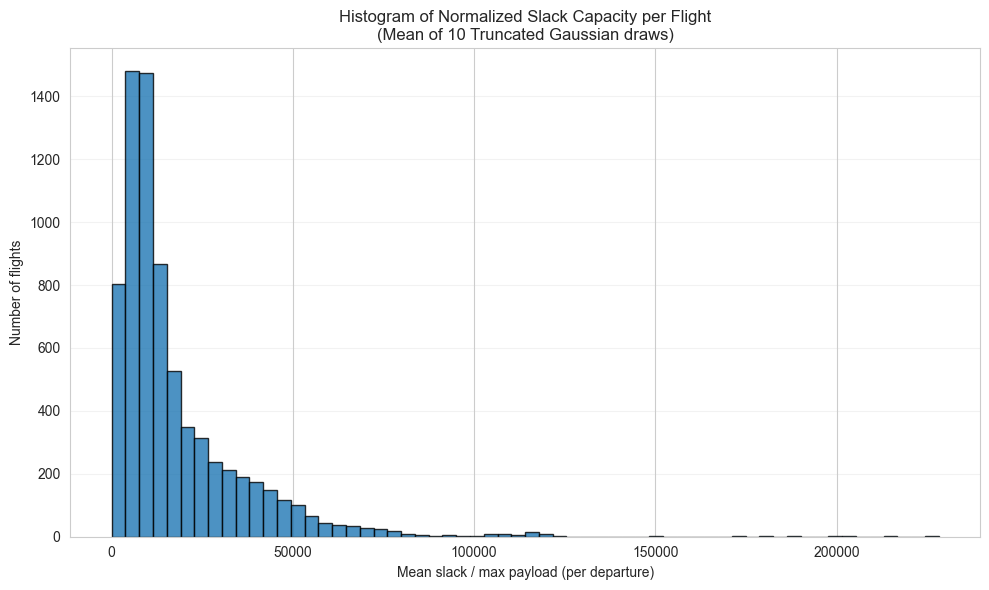

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import truncnorm
import seaborn as sns

sns.set_style("whitegrid")
rng = np.random.default_rng(seed=42)

# Passenger-level moments (same components as before).
mu_pax = 166.7 + 16.8 + 35.1
sigma_pax = np.sqrt(36.8**2 + 11.0**2 + 12.3**2)

# Use only valid rows for per-departure scaling (do not modify `data`).
departures = data["DEPARTURES_PERFORMED"].to_numpy(dtype=float)
valid_mask = departures > 0

u_max = (data.loc[valid_mask, "PAYLOAD"].to_numpy(dtype=float) / departures[valid_mask])
u_cargo = (data.loc[valid_mask, "FREIGHT"].to_numpy(dtype=float) / departures[valid_mask])
u_mail = (data.loc[valid_mask, "MAIL"].to_numpy(dtype=float) / departures[valid_mask])
u_pax = (data.loc[valid_mask, "PASSENGERS"].to_numpy(dtype=float) / departures[valid_mask])

# z | u ~ N(mu_z, sigma_z^2), truncated to z >= 0.
# mu_z = u_max - u_cargo - u_mail - u_pax * mu_pax
# sigma_z^2 = u_pax * sigma_pax^2
mu_z = u_max - u_cargo - u_mail - (u_pax * mu_pax)
sigma_z = np.sqrt(np.maximum(u_pax, 0.0)) * sigma_pax

def truncated_slack_samples(mu, sigma, n_draws, rng):
    mu = np.asarray(mu, dtype=float)
    sigma = np.asarray(sigma, dtype=float)

    n_rows = mu.size

    out = np.zeros((n_rows, n_draws))

    positive_sigma = sigma > 0

    # standardized truncation bounds
    a = (0 - mu[positive_sigma]) / sigma[positive_sigma]
    b = np.full_like(a, np.inf)

    out[positive_sigma] = truncnorm.rvs(
        a[:, None],
        b[:, None],
        loc=mu[positive_sigma][:, None],
        scale=sigma[positive_sigma][:, None],
        size=(positive_sigma.sum(), n_draws),
        random_state=rng,
    )

    # deterministic rows
    out[~positive_sigma] = np.maximum(mu[~positive_sigma], 0.0)[:, None]

    return out

# For each flight, take the average of 10 truncated draws from its slack distribution.
n_draws = 1
slack_draws = truncated_slack_samples(mu_z, sigma_z, n_draws=n_draws, rng=rng)
mean_slack_per_flight = slack_draws.mean(axis=1)

# Normalize by max payload per departure for each flight.
normalized_mean_slack = np.divide(
    mean_slack_per_flight,
    u_max,
    out=np.full_like(mean_slack_per_flight, np.nan),
    where=u_max > 0,
 )
normalized_mean_slack = normalized_mean_slack[np.isfinite(normalized_mean_slack)]

plt.figure(figsize=(10, 6))
plt.hist(mean_slack_per_flight, bins=60, edgecolor="black", alpha=0.8)
plt.title("Histogram of Normalized Slack Capacity per Flight\n(Mean of 10 Truncated Gaussian draws)")
plt.xlabel("Mean slack / max payload (per departure)")
plt.ylabel("Number of flights")
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

Row 33: mu_z = -4739.122580645155
Row 40: mu_z = -576.2516129032228
Row 44: mu_z = -5266.731914893608
Row 45: mu_z = -4872.389189189191
Row 56: mu_z = -3040.61702127659
Row 61: mu_z = -3682.0774193548277
Row 94: mu_z = -5368.986206896538
Row 148: mu_z = -3626.952941176467
Row 163: mu_z = -3133.863414634143
Row 165: mu_z = -7068.561290322585
Row 182: mu_z = -5479.524444444454
Row 204: mu_z = -5233.80000000001
Row 218: mu_z = -2019.2935483870897
Row 222: mu_z = -3564.5999999999913
Row 247: mu_z = -3859.607999999993
Row 250: mu_z = -4932.6095238095295
Row 266: mu_z = -4382.587096774194
Row 268: mu_z = -2599.9741935483908
Row 293: mu_z = -5582.806451612909
Row 299: mu_z = -4495.412903225806
Row 306: mu_z = -4589.777777777774
Row 309: mu_z = -1179.3266666666677
Row 311: mu_z = -1879.2688524590121
Row 314: mu_z = -2874.725925925937
Row 327: mu_z = -1633.8705882353024
Row 355: mu_z = -5080.696774193551
Row 359: mu_z = -197.99333333333198
Row 365: mu_z = -2599.9741935483908
Row 367: mu_z = -37

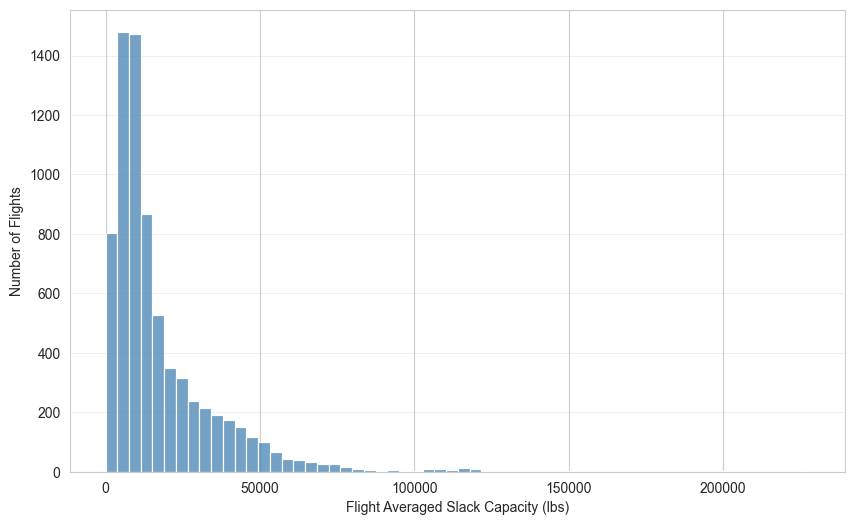

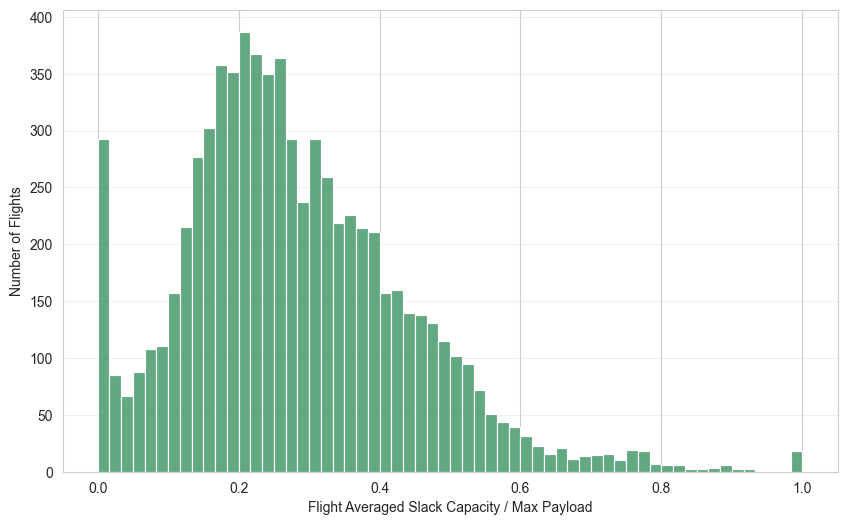

In [13]:
# print all mu_z values <= 0
for i, val in enumerate(mu_z):
    if val <= 0:
        print(f"Row {i}: mu_z = {val}")

# Plot mean and normalized slack distributions and save to parent output/figures
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

figures_dir = Path("../output/figures")
figures_dir.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(10, 6))
sns.histplot(mean_slack_per_flight, bins=60, kde=False, color="steelblue")
plt.xlabel("Flight Averaged Slack Capacity (lbs)")
plt.ylabel("Number of Flights")
plt.grid(axis="y", alpha=0.3)
plt.savefig(figures_dir / "mean_slack_histogram.pdf", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(10, 6))
sns.histplot(normalized_mean_slack, bins=60, kde=False, color="seagreen")
plt.xlabel("Flight Averaged Slack Capacity / Max Payload")
plt.ylabel("Number of Flights")
plt.grid(axis="y", alpha=0.3)
plt.savefig(figures_dir / "normalized_mean_slack_histogram.pdf", dpi=300, bbox_inches="tight")
plt.show()

In [8]:
# Show entries that produce negative raw normalized means.
import numpy as np
import pandas as pd

# Recompute with index alignment to map values back to original rows.
departures_raw = data["DEPARTURES_PERFORMED"].to_numpy(dtype=float)
valid_raw = departures_raw > 0
valid_index = data.index[valid_raw]

u_max_raw = data.loc[valid_raw, "PAYLOAD"].to_numpy(dtype=float) / departures_raw[valid_raw]
u_cargo_raw = data.loc[valid_raw, "FREIGHT"].to_numpy(dtype=float) / departures_raw[valid_raw]
u_mail_raw = data.loc[valid_raw, "MAIL"].to_numpy(dtype=float) / departures_raw[valid_raw]
u_pax_raw = data.loc[valid_raw, "PASSENGERS"].to_numpy(dtype=float) / departures_raw[valid_raw]

mu_raw = u_max_raw - u_cargo_raw - u_mail_raw - (u_pax_raw * mu_pax)
raw_norm = np.divide(
    mu_raw,
    u_max_raw,
    out=np.full_like(mu_raw, np.nan),
    where=u_max_raw > 0,
)

neg_mask = np.isfinite(raw_norm) & (raw_norm < 0)
neg_index = valid_index[neg_mask]

# Show all columns from the original dataframe.
negative_entries = data.loc[neg_index, :].copy()
negative_entries["RAW_NORMALIZED_MEAN"] = raw_norm[neg_mask]
negative_entries = negative_entries.sort_values("RAW_NORMALIZED_MEAN")

print(f"Negative raw normalized mean entries: {negative_entries.shape[0]}")
negative_entries

Negative raw normalized mean entries: 251


,DEPARTURES_SCHEDULED,DEPARTURES_PERFORMED,PAYLOAD,SEATS,PASSENGERS,FREIGHT,MAIL,DISTANCE,RAMP_TO_RAMP,AIR_TIME,UNIQUE_CARRIER,AIRLINE_ID,UNIQUE_CARRIER_NAME,UNIQUE_CARRIER_ENTITY,REGION,CARRIER,CARRIER_NAME,CARRIER_GROUP,CARRIER_GROUP_NEW,ORIGIN_AIRPORT_ID,ORIGIN_AIRPORT_SEQ_ID,ORIGIN_CITY_MARKET_ID,ORIGIN,ORIGIN_CITY_NAME,ORIGIN_COUNTRY,ORIGIN_COUNTRY_NAME,ORIGIN_WAC,DEST_AIRPORT_ID,DEST_AIRPORT_SEQ_ID,DEST_CITY_MARKET_ID,DEST,DEST_CITY_NAME,DEST_COUNTRY,DEST_COUNTRY_NAME,DEST_WAC,AIRCRAFT_GROUP,AIRCRAFT_TYPE,AIRCRAFT_CONFIG,YEAR,QUARTER,MONTH,DISTANCE_GROUP,CLASS,SLACK,RAW_NORMALIZED_MEAN
671,0.0,1.0,28996.0,160.0,145.0,0.0,0.0,1152.0,0.0,0.0,CM,19770,Compania Panamena (Copa),9162C,I,CM,Compania Panamena (Copa),0,0,14286,1428602,34286,PTY,"Panama City, Panama",PA,Panama,162,13303,1330304,32467,MIA,"Miami, FL",US,United States,33,6,612,1,2025,3,7,3,F,28996.000000,-0.093151
672,0.0,1.0,29196.0,160.0,146.0,0.0,0.0,1337.0,0.0,0.0,CM,19770,Compania Panamena (Copa),9162C,I,CM,Compania Panamena (Copa),0,0,13204,1320403,31454,MCO,"Orlando, FL",US,United States,33,14286,1428602,34286,PTY,"Panama City, Panama",PA,Panama,162,6,612,1,2025,3,7,3,F,29196.000000,-0.093150
673,0.0,1.0,29396.0,160.0,147.0,0.0,0.0,2324.0,0.0,0.0,CM,19770,Compania Panamena (Copa),9162C,I,CM,Compania Panamena (Copa),0,0,13930,1393008,30977,ORD,"Chicago, IL",US,United States,41,14286,1428602,34286,PTY,"Panama City, Panama",PA,Panama,162,6,612,1,2025,3,7,5,F,29396.000000,-0.093149
681,0.0,1.0,30796.0,160.0,154.0,0.0,0.0,1152.0,0.0,0.0,CM,19770,Compania Panamena (Copa),9162C,I,CM,Compania Panamena (Copa),0,0,13303,1330304,32467,MIA,"Miami, FL",US,United States,33,14286,1428602,34286,PTY,"Panama City, Panama",PA,Panama,162,6,612,1,2025,3,7,3,F,30796.000000,-0.093142
4851,0.0,32.0,218176.0,1600.0,1091.0,0.0,0.0,183.0,0.0,0.0,WU,22123,Western Air Ltd,71286,I,WU,Western Air Ltd,0,0,11697,1169707,32467,FLL,"Fort Lauderdale, FL",US,United States,33,13605,1360506,33605,NAS,"Nassau, The Bahamas",BS,The Bahamas,204,6,675,1,2025,3,7,1,F,6818.000000,-0.093120
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6715,5.0,5.0,230000.0,1150.0,1054.0,0.0,0.0,1514.0,1205.0,1037.0,F9,20436,Frontier Airlines Inc.,16461,L,F9,Frontier Airlines Inc.,3,3,14739,1473906,32105,SDQ,"Santo Domingo, Dominican Republic",DO,Dominican Republic,224,14100,1410006,34100,PHL,"Philadelphia, PA",US,United States,23,6,699,1,2025,3,7,4,F,46000.000000,-0.001758
5198,0.0,62.0,2197155.0,10649.0,10067.0,37.0,0.0,2375.0,0.0,0.0,AV,19537,Aerovias Nacl De Colombia,9327A,I,AV,Aerovias Nacl De Colombia,0,0,12478,1247805,31703,JFK,"New York, NY",US,United States,22,13218,1321801,31565,MDE,"Medellin, Colombia",CO,Colombia,327,6,694,1,2025,3,7,5,F,35437.387097,-0.001606
1743,0.0,2.0,66400.0,332.0,304.0,0.0,0.0,1720.0,0.0,0.0,CM,19770,Compania Panamena (Copa),9162C,I,CM,Compania Panamena (Copa),0,0,14286,1428602,34286,PTY,"Panama City, Panama",PA,Panama,162,10397,1039708,30397,ATL,"Atlanta, GA",US,United States,34,6,839,1,2025,3,7,4,F,33200.000000,-0.000819
8062,30.0,30.0,1056000.0,5280.0,4834.0,0.0,0.0,913.0,4295.0,3582.0,NK,20416,Spirit Air Lines,16831,L,NK,Spirit Air Lines,3,3,11697,1169707,32467,FLL,"Fort Lauderdale, FL",US,United States,33,14293,1429304,34293,PUJ,"Punta Cana, Dominican Republic",DO,Dominican Republic,224,6,694,1,2025,3,7,2,F,35200.000000,-0.000675


In [9]:
mu_pax

218.6

In [ ]:
import gurobipy as gp
from gurobipy import GRB
import numpy as np
from scipy.stats import norm

# Make cell runnable even if previous cells were not executed
if "z_sampler" not in globals():
    rng_seed = np.random.default_rng(seed=42)
    mu_pax = 166.7 + 16.8 + 35.1
    sigma_pax = np.sqrt(36.8**2 + 11.0**2 + 12.3**2)

    def truncated_slack_samples(mu, sigma, n_draws, rng):
        mu = np.asarray(mu, dtype=float)
        sigma = np.asarray(sigma, dtype=float)
        out = np.empty((mu.shape[0], n_draws), dtype=float)

        positive_sigma = sigma > 0
        zero_sigma = ~positive_sigma

        if np.any(positive_sigma):
            mu_pos = mu[positive_sigma]
            sigma_pos = sigma[positive_sigma]
            alpha = (0.0 - mu_pos) / sigma_pos
            cdf_low = norm.cdf(alpha)
            u = rng.uniform(cdf_low[:, None], 1.0, size=(mu_pos.shape[0], n_draws))
            out[positive_sigma] = mu_pos[:, None] + sigma_pos[:, None] * norm.ppf(u)

        if np.any(zero_sigma):
            out[zero_sigma] = np.maximum(mu[zero_sigma], 0.0)[:, None]

        return out

    def z_sampler(u_max, u_cargo, u_mail, u_pax, n):
        mu = u_max - u_cargo - u_mail - u_pax * mu_pax
        sigma = np.sqrt(np.maximum(u_pax, 0.0)) * sigma_pax
        mu_arr = np.atleast_1d(np.asarray(mu, dtype=float))
        sigma_arr = np.atleast_1d(np.asarray(sigma, dtype=float))
        draws = truncated_slack_samples(mu_arr, sigma_arr, n_draws=n, rng=rng_seed)
        if np.ndim(mu) == 0 and np.ndim(sigma) == 0:
            return draws[0]
        return draws

# --------------------------
# Sets (temporary toy sizes)
# --------------------------
# Kept intentionally small to fit size-limited Gurobi licenses
S = list(range(6))                      # shipments
R = list(range(3))                      # routes
A = list(range(2))                      # carriers/aircraft options
Omega = list(range(6))                  # sampled capacity scenarios

# Use a local RNG for reproducibility on each run of this cell
rng = np.random.default_rng(seed=42)

# -----------------------------------
# Temporary cost and data placeholders
# -----------------------------------
c_flight = 1200.0
c_truck = 2.0
c_penalty = 5000.0

# Distance per route d_{l,d} (temporary values)
d = {r: float(rng.uniform(200, 1200)) for r in R}

# Shipment weights w_s (temporary values)
w = {s: float(rng.uniform(2.0, 12.0)) for s in S}
total_weight = sum(w.values())
max_weight = max(w.values())

# -----------------------------------------------
# Scenario-dependent capacities V[(a,r,om)]
# Build each scenario to be feasible by construction:
# for each scenario, create a random shipment-to-bin pattern, then
# set each bin capacity to that load plus random headroom.
# -----------------------------------------------
V = {}
scenario_total_capacity = {}
scenario_max_bin_capacity = {}

bins = [(a, r) for a in A for r in R]

for om in Omega:
    # Random feasible pattern for this scenario
    base_load = {(a, r): 0.0 for (a, r) in bins}
    for s in S:
        a_s, r_s = bins[int(rng.integers(0, len(bins)))]
        base_load[(a_s, r_s)] += w[s]

    # Add random headroom to preserve uncertainty but keep feasibility
    for (a, r) in bins:
        headroom_factor = float(rng.uniform(1.05, 1.30))
        additive_buffer = float(rng.uniform(0.1, 1.0))
        cap = base_load[(a, r)] * headroom_factor + additive_buffer
        V[(a, r, om)] = cap

    scenario_total_capacity[om] = float(sum(V[(a, r, om)] for (a, r) in bins))
    scenario_max_bin_capacity[om] = float(max(V[(a, r, om)] for (a, r) in bins))

# -------------
# Build model
# -------------
m = gp.Model("two_stage_stochastic_shipment")

# First-stage decision: assign each shipment before uncertainty realization
x = m.addVars(S, R, A, vtype=GRB.BINARY, name="x")

# Second-stage recourse decisions per scenario
y = m.addVars(S, R, A, Omega, lb=0.0, vtype=GRB.CONTINUOUS, name="y")
z = m.addVars(S, R, A, Omega, vtype=GRB.BINARY, name="z")

# First-stage deterministic assignment cost
first_stage_cost = gp.quicksum(
    (c_flight + c_truck * d[r]) * x[s, r, a]
    for s in S for r in R for a in A
)

# SAA empirical mean recourse cost: (1/|Omega|) * sum_{om in Omega} Q_om
expected_recourse = (1.0 / len(Omega)) * gp.quicksum(
    gp.quicksum(
        (c_flight + c_truck * d[r] + c_penalty) * y[s, r, a, om]
        for s in S for r in R for a in A
    )
    for om in Omega
)

m.setObjective(first_stage_cost + expected_recourse, GRB.MINIMIZE)

# ------------------
# First-stage constraints
# ------------------
# Sum_{(i,j),a} x = 1, for each shipment s
m.addConstrs(
    (gp.quicksum(x[s, r, a] for r in R for a in A) == 1 for s in S),
    name="first_stage_assign"
)

# -------------------
# Second-stage constraints
# -------------------
# Sum_{(i,j),a} z = 1, for each shipment s and scenario om
m.addConstrs(
    (gp.quicksum(z[s, r, a, om] for r in R for a in A) == 1 for s in S for om in Omega),
    name="second_stage_assign"
)

# y >= z - x, for each (s,r,a,om)
m.addConstrs(
    (y[s, r, a, om] >= z[s, r, a, om] - x[s, r, a]
     for s in S for r in R for a in A for om in Omega),
    name="recourse_link"
)

# Sum_s w_s z_{s,r,a,om} <= V(a,r,om), for each (a,r,om)
m.addConstrs(
    (gp.quicksum(w[s] * z[s, r, a, om] for s in S) <= V[(a, r, om)]
     for a in A for r in R for om in Omega),
    name="capacity"
)

m.Params.OutputFlag = 1
m.optimize()

# -------------
# Quick summary
# -------------
if m.Status == GRB.OPTIMAL:
    print(f"Optimal objective: {m.ObjVal:,.2f}")
    print(f"First-stage cost: {first_stage_cost.getValue():,.2f}")
    print(f"SAA mean recourse cost: {expected_recourse.getValue():,.2f}")
    print(f"Max shipment weight: {max_weight:.2f}")

    print("\nScenario capacity diagnostics:")
    for om in Omega:
        print(
            f"  scenario {om}: total={scenario_total_capacity[om]:.2f}, "
            f"max-bin={scenario_max_bin_capacity[om]:.2f}"
        )

    print("\nFirst-stage assignments (x=1):")
    for s in S:
        for r in R:
            for a in A:
                if x[s, r, a].X > 0.5:
                    print(f"  shipment {s} -> route {r}, carrier {a}")
else:
    print(f"Model ended with status code {m.Status}")
    if m.Status == GRB.INFEASIBLE:
        print("Unexpected infeasibility under feasible-by-construction V^omega.")
        print("Check for accidental edits to assignment/capacity constraints.")

Set parameter OutputFlag to value 1
Gurobi Optimizer version 12.0.3 build v12.0.3rc0 (win64 - Windows 11.0 (26100.2))

CPU model: 11th Gen Intel(R) Core(TM) i7-1165G7 @ 2.80GHz, instruction set [SSE2|AVX|AVX2|AVX512]
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 294 rows, 504 columns and 1152 nonzeros
Model fingerprint: 0xdd792dee
Variable types: 216 continuous, 288 integer (288 binary)
Coefficient statistics:
  Matrix range     [1e+00, 3e+05]
  Objective range  [2e+03, 1e+04]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 4e+05]
Found heuristic solution: objective 131952.00000
Presolve removed 123 rows and 246 columns
Presolve time: 0.00s
Presolved: 171 rows, 258 columns, 599 nonzeros
Found heuristic solution: objective 130934.00000
Variable types: 0 continuous, 258 integer (258 binary)
Found heuristic solution: objective 102934.00000

Root relaxation: objective 7.893400e+04, 168 iterations, 0.00 seconds (0.00 work uni

In [7]:
import airportsdata as ad

airports = ad.load("IATA")
city = 'OUAGADOUGOU'

# find where the city is in the airports data
for code, info in airports.items():
    if info['city'] == city:
        print(f"Found {city} in airports data: code={code}, info={info}")

print(airports.get('OUA'))

{'icao': 'DFFD', 'iata': 'OUA', 'name': 'Ouagadougou Airport', 'city': 'Ouagadougou', 'subd': '', 'country': 'BF', 'elevation': 1037.0, 'lat': 12.3532, 'lon': -1.51242, 'tz': 'Africa/Ouagadougou', 'lid': ''}
